# 03 Customer segmentation

RFM inputs, skew and outliers, choosing k, and reading the fitted segments.

> Data: Online Retail II, UCI Machine Learning Repository (Chen, 2019, CC BY 4.0). Historical transactions from 1 Dec 2009 to 9 Dec 2011. This notebook reads the PostgreSQL tables produced by `gci import-data`, `gci build-analytics`, `gci build-features` and `gci train`; reusable logic lives in the `gci` package, not here.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import text
from gci.db.session import session_scope
from gci.api.sqlfiles import load_sql
sns.set_theme(style="whitegrid", palette=["#1D4ED8", "#94A3B8", "#0F1F3D", "#B45309"])
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
GBP = lambda v: f"£{v:,.0f}"

def q(sql, **params):
    with session_scope() as s:
        return pd.read_sql(text(sql) if isinstance(sql, str) else sql, s.connection(), params=params)

def findings(items):
    display(Markdown("\n".join(f"{i+1}. {t}" for i, t in enumerate(items))))

## 1. RFM inputs at the scoring cutoff

Recency, frequency and monetary value are taken from the scoring snapshot (features strictly before 10 December 2011, lookback 365 days).

5,852 customers at cutoff 2011-12-10


,count,mean,std,min,50%,90%,99%,max
recency_days,"5,852.00",199.73,208.52,0.00,95.00,530.00,726.00,738.00
orders_lookback,"5,852.00",3.01,6.52,0.00,1.00,7.00,25.00,190.00
spend_lookback,"5,852.00","1,440.35","7,473.59",0.00,355.56,"2,726.72","14,579.87","279,138.02"


Skewness before log1p: {'recency_days': 0.89, 'orders_lookback': 12.48, 'spend_lookback': 22.37}
Skewness after log1p:  {'recency_days': -0.55, 'orders_lookback': 0.74, 'spend_lookback': -0.63}


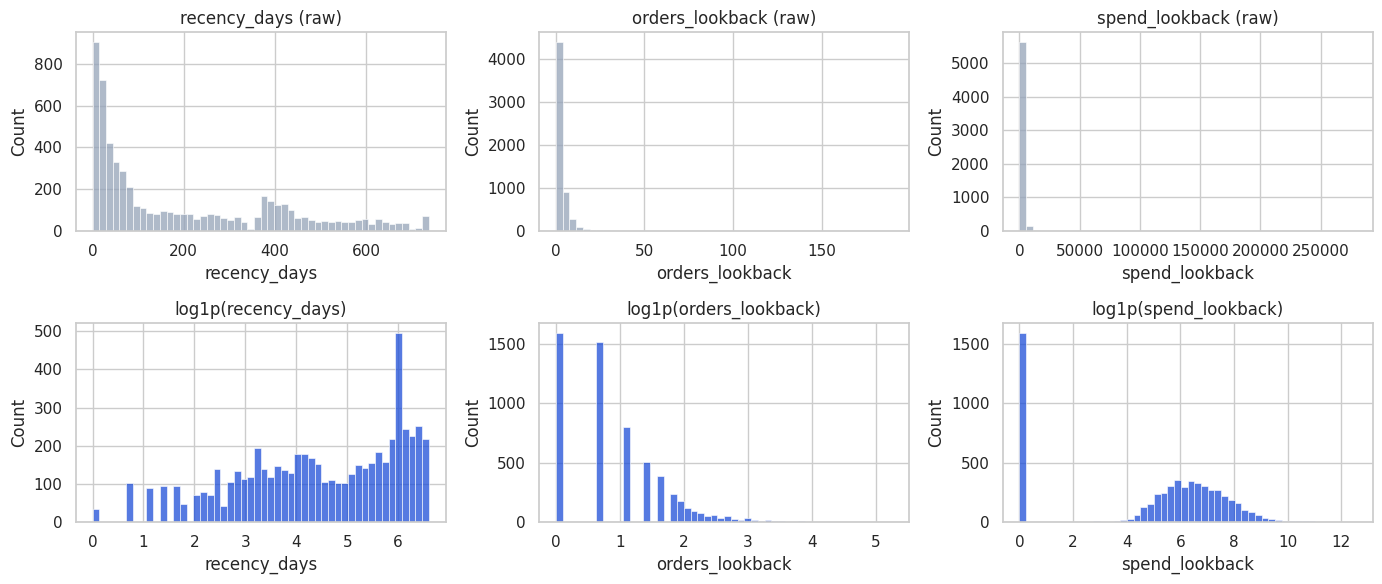

Customers above the 99th percentile: {'recency_days': 56, 'orders_lookback': 53, 'spend_lookback': 59} - kept; the log transform and scaling limit their pull on the centroids.


In [2]:
from gci.features.snapshots import load_snapshots
from gci.ml.segmentation import RFM_COLUMNS, evaluate_k_range, make_pipeline, name_clusters, select_k
from scipy.stats import skew
with session_scope() as s:
    snaps = load_snapshots(s, ["scoring"])
X = snaps[RFM_COLUMNS].astype(float)
print(f"{len(X):,} customers at cutoff {snaps.cutoff_date.iloc[0]}"); display(X.describe(percentiles=[.5,.9,.99]).T)
print("Skewness before log1p:", {c: round(float(skew(X[c])),2) for c in RFM_COLUMNS})
print("Skewness after log1p: ", {c: round(float(skew(np.log1p(X[c]))),2) for c in RFM_COLUMNS})
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, c in enumerate(RFM_COLUMNS):
    sns.histplot(X[c], bins=50, ax=axes[0, i], color="#94A3B8"); axes[0, i].set_title(f"{c} (raw)")
    sns.histplot(np.log1p(X[c]), bins=50, ax=axes[1, i], color="#1D4ED8"); axes[1, i].set_title(f"log1p({c})")
plt.tight_layout(); plt.show()
print("Customers above the 99th percentile:", {c: int((X[c] > X[c].quantile(.99)).sum()) for c in RFM_COLUMNS}, "- kept; the log transform and scaling limit their pull on the centroids.")

## 2. Comparing cluster counts

Silhouette (cohesion/separation), bootstrap stability (adjusted Rand index between the full fit and refits on 80% subsamples) and the smallest cluster share.

,k,silhouette,stability_ari,min_cluster_share,inertia
0,3,0.57,1.00,0.27,"3,285.02"
1,4,0.51,0.95,0.12,"2,408.77"
2,5,0.52,0.96,0.10,"1,880.45"
3,6,0.52,0.99,0.07,"1,518.47"
4,7,0.51,0.96,0.04,"1,309.17"


Selected k = 6 | largest k with silhouette within 0.05 of the best (0.566), min cluster share >= 2% and bootstrap ARI >= 0.6


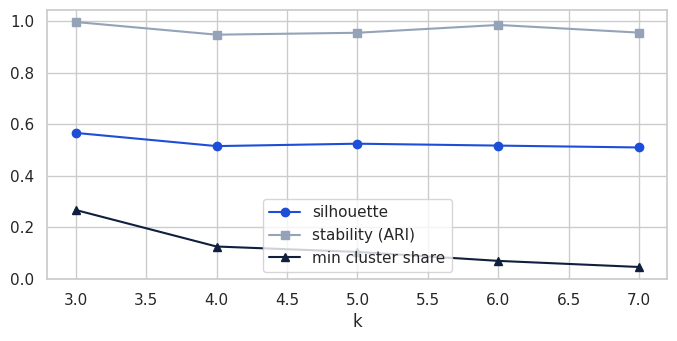

In [3]:
comparison = pd.DataFrame(evaluate_k_range(X)); display(comparison)
k, rule = select_k(comparison.to_dict("records")); print("Selected k =", k, "|", rule)
fig, ax = plt.subplots(figsize=(8, 3.5)); ax.plot(comparison.k, comparison.silhouette, marker="o", label="silhouette"); ax.plot(comparison.k, comparison.stability_ari, marker="s", label="stability (ARI)"); ax.plot(comparison.k, comparison.min_cluster_share, marker="^", label="min cluster share"); ax.set_xlabel("k"); ax.legend(); plt.show()

## 3. The active segmentation and its profiles

The fitted preprocessing + K-means pipeline is loaded from the model store; names were derived from the cluster medians after fitting.

segmentation-20260921-200419 | KMeans(k=6) on log1p-scaled RFM | silhouette 0.517 | stability 0.986


,segment_name,customers,share,median_recency_days,median_frequency,median_monetary,revenue_share
0,Recent top-value,401,0.07,7.00,13.00,"4,762.18",0.52
1,Active high-value,1026,0.18,42.00,4.00,"1,431.86",0.24
2,Recent high-value,552,0.09,7.00,4.00,"1,023.79",0.11
3,Active mid-value,1051,0.18,43.00,1.00,354.25,0.06
4,Lapsing mid-value,1230,0.21,211.00,1.00,307.50,0.07
5,Inactive (no purchase in 365 days),1592,0.27,467.00,0.00,0.00,0.00


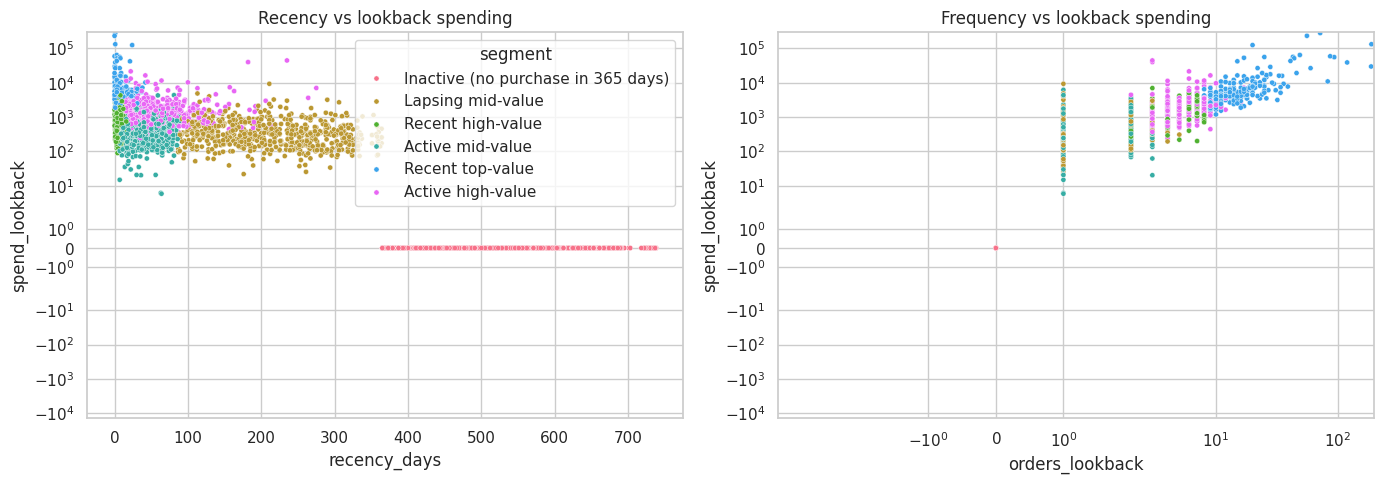

In [4]:
from gci.ml.tracking import active_run, load_artifact
with session_scope() as s:
    run = active_run(s, "segmentation"); pipe = load_artifact(run.artifact_path, "model.joblib"); profiles = pd.DataFrame(run.metrics["profiles"])
print(run.model_version, "|", run.algorithm, "| silhouette", round(run.metrics["silhouette"], 3), "| stability", round(run.metrics["stability_ari"], 3))
display(profiles[["segment_name","customers","share","median_recency_days","median_frequency","median_monetary","revenue_share"]])
labels = pipe.predict(X); names = profiles.set_index("cluster_id").segment_name
plot = X.assign(segment=[names[c] for c in labels])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=plot.sample(3000, random_state=1), x="recency_days", y="spend_lookback", hue="segment", s=14, ax=axes[0]); axes[0].set_yscale("symlog"); axes[0].set_title("Recency vs lookback spending")
sns.scatterplot(data=plot.sample(3000, random_state=1), x="orders_lookback", y="spend_lookback", hue="segment", s=14, ax=axes[1], legend=False); axes[1].set_xscale("symlog"); axes[1].set_yscale("symlog"); axes[1].set_title("Frequency vs lookback spending")
plt.tight_layout(); plt.show()

## 4. Interpretation and findings

In [5]:
top = profiles.iloc[0]; inactive = profiles[profiles.median_monetary == 0]
findings([
 f"The selection rule picked k={k}: silhouette {run.metrics['silhouette']:.2f} is within 0.05 of the best value across k=3-7 while every cluster stays stable (ARI {run.metrics['stability_ari']:.2f}) and above 2% of customers.",
 f"'{top.segment_name}' is {top.share:.0%} of customers but holds {top.revenue_share:.0%} of lookback spending (median {GBP(top.median_monetary)}, {top.median_frequency:.0f} orders, last purchase {top.median_recency_days:.0f} days ago).",
 (f"'{inactive.iloc[0].segment_name}' contains {inactive.iloc[0].share:.0%} of identified customers with no eligible purchase in the last 365 days; they are a natural cluster, not a rule-based cut." if len(inactive) else "No cluster is purely inactive."),
 "Segment boundaries are soft: log-scaling reduces skew but customers near a boundary could reasonably belong to a neighbouring segment, so segments are descriptive groupings for review, not verdicts.",
 "All three inputs are computed before the cutoff, so the segmentation describes past behaviour only; it does not predict what a customer will do next (that is the classifier's job).",
])

1. The selection rule picked k=6: silhouette 0.52 is within 0.05 of the best value across k=3-7 while every cluster stays stable (ARI 0.99) and above 2% of customers.
2. 'Recent top-value' is 7% of customers but holds 52% of lookback spending (median £4,762, 13 orders, last purchase 7 days ago).
3. 'Inactive (no purchase in 365 days)' contains 27% of identified customers with no eligible purchase in the last 365 days; they are a natural cluster, not a rule-based cut.
4. Segment boundaries are soft: log-scaling reduces skew but customers near a boundary could reasonably belong to a neighbouring segment, so segments are descriptive groupings for review, not verdicts.
5. All three inputs are computed before the cutoff, so the segmentation describes past behaviour only; it does not predict what a customer will do next (that is the classifier's job).